# SIG Spectra Visualization

This notebook loads processed SVC `.sig` files, visualizes individual spectra, and plots mean/median curves to support quick QA before deeper analysis.

In [48]:
!pip install specdal

In [49]:
import sys
from pathlib import Path

project_root = Path.cwd().parents[0]  # one level up from notebooks/
sys.path.insert(0, str(project_root))
project_root

PosixPath('/Users/nr466/Python Projects/svcProcessingPipeline')

## Load processed spectra into a SpecDAL Collection

In [50]:
from specdal import Collection
from pathlib import Path
import os 
PROCESSED_DIR = os.path.join(project_root, "pipeline_outputs/sig_processed")
example_folder = "72924_Crittenden_SVC_Silver" # REPLACE WITH YOUR FOLDER NAME
processed_example_dir = Path(PROCESSED_DIR) / example_folder
collection = Collection(name=processed_example_dir.name or 'processed_spectra')
collection.read(directory=str(processed_example_dir))
print(f"Loaded {len(collection.spectra)} spectra from {processed_example_dir}")


Loaded 138 spectra from /Users/nr466/Python Projects/svcProcessingPipeline/pipeline_outputs/sig_processed/72924_Crittenden_SVC_Silver


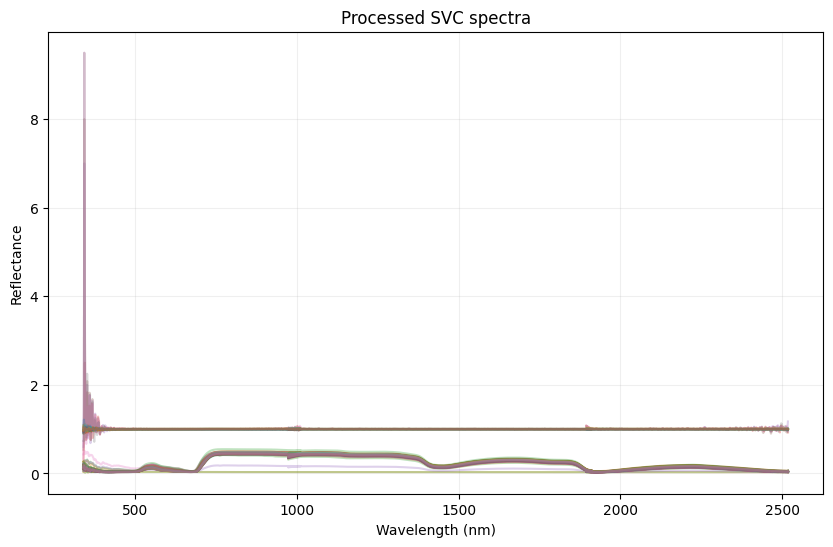

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 6))
for spectrum in collection.spectra:
    measurement = spectrum.measurement
    ax.plot(measurement.index, measurement.values, alpha=0.3)

ax.set_title('Pre-Processed SVC spectra')
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Reflectance')
ax.grid(alpha=0.2)
plt.show()


In [52]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
processed_spectra_dir = Path("/Users/nr466/Python Projects/svcProcessingPipeline/pipeline_outputs/sig_resampled")
PROCESSED_SPECTRA_CSV_PATHS = {
    '72224_Crittenden_SVC_Bronze': Path(processed_spectra_dir) / '72224_Crittenden_SVC_Bronze' / '72224_Crittenden_SVC_Silver_merged_spectra.csv',
    '72924_Crittenden_SVC_Silver': Path(processed_spectra_dir) / '72924_Crittenden_SVC_Silver' / '72924_Crittenden_SVC_Silver_merged_spectra.csv',

}
merged_df = pd.read_csv(PROCESSED_SPECTRA_CSV_PATHS[example_folder]).iloc[1:] #we can just use the example folder variable defined earlier



merged_df.head()

,sample_name,400,401,402,403,404,405,406,407,408,...,2491,2492,2493,2494,2495,2496,2497,2498,2499,2500
1,HR.123108.CT.S.0001.sig,0.039097,0.039137,0.039203,0.039287,0.039378,0.039468,0.039551,0.039622,0.039677,...,0.028015,0.028060,0.028102,0.028133,0.028143,0.028130,0.028096,0.028050,0.028001,0.027964
2,HR.123108.CT.S.0002.sig,0.039805,0.039794,0.039769,0.039738,0.039711,0.039697,0.039703,0.039729,0.039768,...,0.027969,0.028034,0.028101,0.028168,0.028228,0.028277,0.028311,0.028329,0.028331,0.028321
3,HR.123108.CT.S.0003.sig,0.999029,0.999855,1.001008,1.002487,1.004274,1.006296,1.008433,1.010534,1.012449,...,0.987513,0.991254,0.996168,1.001958,1.008190,1.014360,1.019970,1.024599,1.027962,1.029925
4,HR.123108.CT.S.0004.sig,1.005652,1.007132,1.008345,1.009574,1.011066,1.012905,1.014952,1.016885,1.018302,...,1.027858,1.028658,1.029212,1.029474,1.029390,1.028921,1.028068,1.026885,1.025475,1.023974
5,HR.123108.CT.S.0005.sig,0.996116,0.999064,1.001699,1.004011,1.006010,1.007704,1.009090,1.010169,1.010960,...,1.015584,1.017741,1.019663,1.021045,1.021586,1.021047,1.019299,1.016352,1.012363,1.007604


In [53]:
import numpy as np
import matplotlib.pyplot as plt

def plot_resampled_spectra(df, sample_col="sample_name", max_samples=None):
    """
    Plot spectra from a wide dataframe where each row is a sample and spectral
    columns are labeled with wavelengths (e.g., '350' or 'X350').

    Args:
        df (pd.DataFrame): resampled spectra table.
        sample_col (str): column holding the sample names/ids.
        max_samples (int | None): optional limit on the number of lines to plot.
    """
    if sample_col not in df.columns:
        raise KeyError(f"Column '{sample_col}' not found.")

    spectral_cols = [
        col for col in df.columns
        if str(col).lower() not in {sample_col.lower(), "sample"}
    ]

    band_pairs = []
    for col in spectral_cols:
        cleaned = str(col).lstrip("Xx")
        if cleaned.isdigit():
            band_pairs.append((int(cleaned), col))

    if not band_pairs:
        raise ValueError("No spectral columns detected (expected numeric or X-prefixed names).")

    band_pairs.sort(key=lambda pair: pair[0])
    wavelengths = [w for w, _ in band_pairs]
    ordered_cols = [col for _, col in band_pairs]

    fig, ax = plt.subplots(figsize=(12, 6))
    rows = df if max_samples is None else df.head(max_samples)

    for _, row in rows.iterrows():
        sample = row[sample_col]
        reflectance = row[ordered_cols].to_numpy(dtype=float)
        ax.plot(wavelengths, reflectance, label=sample)

    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("Reflectance")
    ax.set_title("Resampled Spectra by Sample")
    if len(rows) <= 10:
        ax.legend(loc="upper right", fontsize="small")
    else:
        ax.legend(loc="upper right", fontsize="small", ncol=2)

    plt.show()


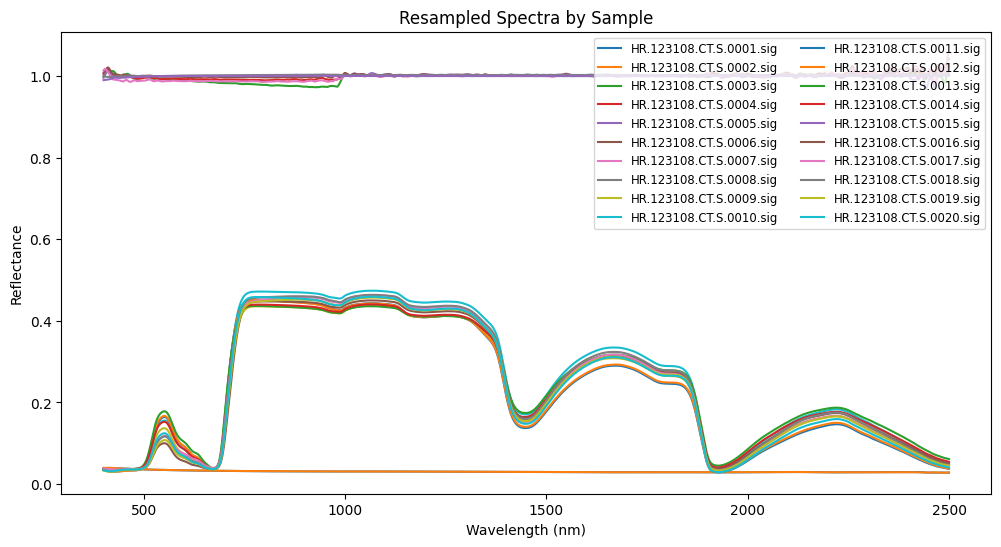

In [54]:
plot_resampled_spectra(merged_df, sample_col="sample_name", max_samples=20)